# Time Series Analysis & Forecasting for Multiple Humidity Sensors in a Warehouse (SARIMA-RawData2)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm

In [2]:
file_path = r"C:\\Users\\sulaiman.at\\Documents\\GitHub\\TSA&F-Humidity-Warehouse\\RawData2.xls"
# Load the data
data = pd.read_excel(file_path, engine="xlrd", sheet_name=None) # Load all sheets into a dictionary

# Combine sheets (assuming common date column)
combined_df = pd.DataFrame()
for sheet_name, df in data.items():
    df['SourceSheet'] = sheet_name # Optional: track source
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Set the date column as the index
combined_df['Date'] = pd.to_datetime(combined_df['Time'])
combined_df.set_index('Date', inplace=True)

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


In [3]:
combined_df.head()

,Index,Time,CH01(%),CH02(%),CH03(%),CH04(%),CH05(%),CH06(%),SourceSheet
Date,,,,,,,,,
2025-02-27 10:04:44,1,02/27/2025 10:04:44 AM,80.21,78.64,76.12,77.16,78.87,78.25,sheet1
2025-02-27 10:05:04,2,02/27/2025 10:05:04 AM,80.08,78.63,76.11,77.18,78.87,78.12,sheet1
2025-02-27 10:05:24,3,02/27/2025 10:05:24 AM,79.94,78.63,76.12,77.15,78.85,78.09,sheet1
2025-02-27 10:05:44,4,02/27/2025 10:05:44 AM,79.95,78.64,76.11,77.28,78.85,78.12,sheet1
2025-02-27 10:06:04,5,02/27/2025 10:06:04 AM,79.92,78.62,76.11,77.17,78.84,78.12,sheet1


In [4]:
combined_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 39212 entries, 2025-02-27 10:04:44 to 2025-03-08 11:55:04
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Index        39212 non-null  int64  
 1   Time         39212 non-null  str    
 2   CH01(%)      39212 non-null  float64
 3   CH02(%)      39212 non-null  float64
 4   CH03(%)      39212 non-null  float64
 5   CH04(%)      39212 non-null  float64
 6   CH05(%)      39212 non-null  float64
 7   CH06(%)      39212 non-null  float64
 8   SourceSheet  39212 non-null  str    
dtypes: float64(6), int64(1), str(2)
memory usage: 3.0 MB


In [5]:

# Convert Time column from string to datetime
combined_df['Time'] = pd.to_datetime(combined_df['Time'], format='mixed')

# Set Time as index for time series analysis
combined_df = combined_df.set_index('Time')


In [6]:
combined_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 39212 entries, 2025-02-27 10:04:44 to 2025-03-08 11:55:04
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Index        39212 non-null  int64  
 1   CH01(%)      39212 non-null  float64
 2   CH02(%)      39212 non-null  float64
 3   CH03(%)      39212 non-null  float64
 4   CH04(%)      39212 non-null  float64
 5   CH05(%)      39212 non-null  float64
 6   CH06(%)      39212 non-null  float64
 7   SourceSheet  39212 non-null  str    
dtypes: float64(6), int64(1), str(1)
memory usage: 2.7 MB


In [7]:
combined_df.index.is_monotonic_increasing

# If returns False, sort the index
# combined_df = combined_df.sort_index()

True

In [8]:
# Remove impossible humidity values
combined_df = combined_df.replace(-32640, pd.NA)

# Drop rows where all channels are missing
combined_df = combined_df.dropna(how='all')

# Drop the source sheet column if it exists
combined_df = combined_df.drop(columns=['SourceSheet'], errors='ignore') 

In [9]:
combined_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 39212 entries, 2025-02-27 10:04:44 to 2025-03-08 11:55:04
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Index    39212 non-null  int64  
 1   CH01(%)  39212 non-null  float64
 2   CH02(%)  39212 non-null  float64
 3   CH03(%)  39212 non-null  float64
 4   CH04(%)  39212 non-null  float64
 5   CH05(%)  39212 non-null  float64
 6   CH06(%)  39212 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 2.4 MB


In [10]:
combined_df.head()

,Index,CH01(%),CH02(%),CH03(%),CH04(%),CH05(%),CH06(%)
Time,,,,,,,
2025-02-27 10:04:44,1,80.21,78.64,76.12,77.16,78.87,78.25
2025-02-27 10:05:04,2,80.08,78.63,76.11,77.18,78.87,78.12
2025-02-27 10:05:24,3,79.94,78.63,76.12,77.15,78.85,78.09
2025-02-27 10:05:44,4,79.95,78.64,76.11,77.28,78.85,78.12
2025-02-27 10:06:04,5,79.92,78.62,76.11,77.17,78.84,78.12


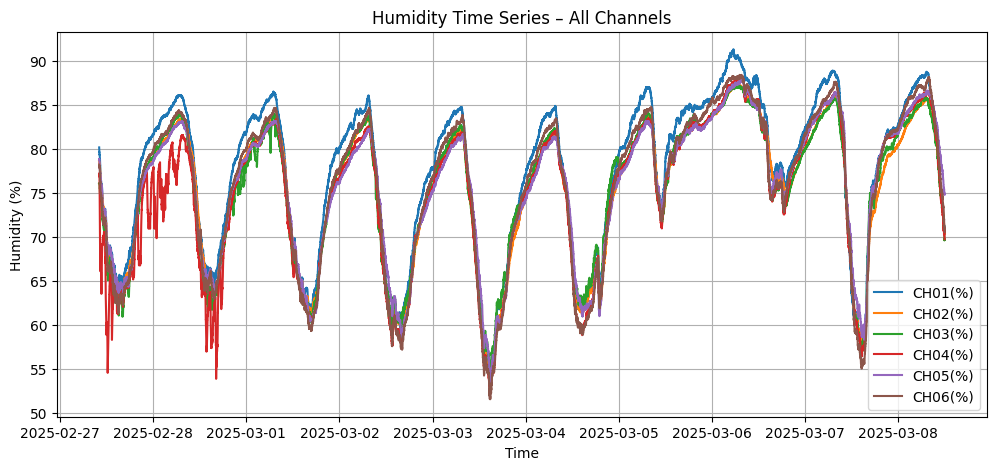

In [11]:

# Convert all columns to numeric and coerce errors to NaN (in case there are any non-numeric values)
combined_df = combined_df.apply(pd.to_numeric, errors='coerce')

# Drop the non-sensor column if it exists
combined_df = combined_df.drop(columns=['Index'], errors='ignore')

plt.figure(figsize=(12,5))
for col in combined_df.columns:
    plt.plot(combined_df.index, combined_df[col], label=col)

plt.title("Humidity Time Series – All Channels")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
# Perform ADF test for each channel
for column in combined_df.columns:
    print(f"ADF Test for {column}:")
    result = adfuller(combined_df[column].dropna()) # dropna() to handle potential missing values
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print(f"Critical Values: {result[4]}")
    print(f"Is Stationary: {result[1] < 0.05}\n")

ADF Test for CH01(%):
ADF Statistic: -2.6559421856539145
p-value: 0.08197736365834302
Critical Values: {'1%': np.float64(-3.430517013017757), '5%': np.float64(-2.8616138158734055), '10%': np.float64(-2.5668092898265154)}
Is Stationary: False

ADF Test for CH02(%):
ADF Statistic: -2.9790361838109107
p-value: 0.036899079787902266
Critical Values: {'1%': np.float64(-3.430517013017757), '5%': np.float64(-2.8616138158734055), '10%': np.float64(-2.5668092898265154)}
Is Stationary: True

ADF Test for CH03(%):
ADF Statistic: -2.518469823454057
p-value: 0.11104484692889521
Critical Values: {'1%': np.float64(-3.430516991693008), '5%': np.float64(-2.8616138064486267), '10%': np.float64(-2.566809284809961)}
Is Stationary: False

ADF Test for CH04(%):
ADF Statistic: -2.848587337767426
p-value: 0.05166157011998488
Critical Values: {'1%': np.float64(-3.430517004487204), '5%': np.float64(-2.8616138121032053), '10%': np.float64(-2.5668092878197397)}
Is Stationary: False

ADF Test for CH05(%):
ADF Stati

**Seasonal Differencing (Trend + Seasonality)**

In [34]:
first_diff = combined_df.diff()
first_diff.dropna(inplace=True)
second_diff = combined_df.diff().diff()
second_diff.dropna(inplace=True)

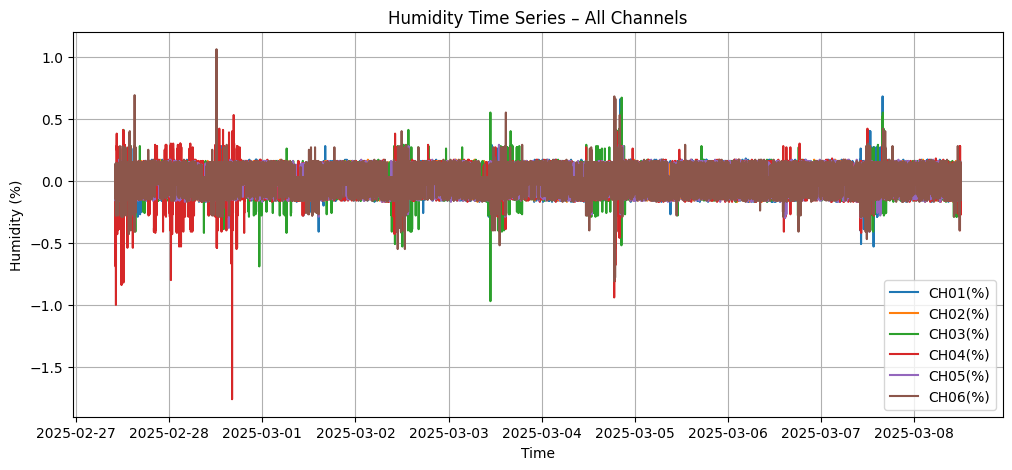

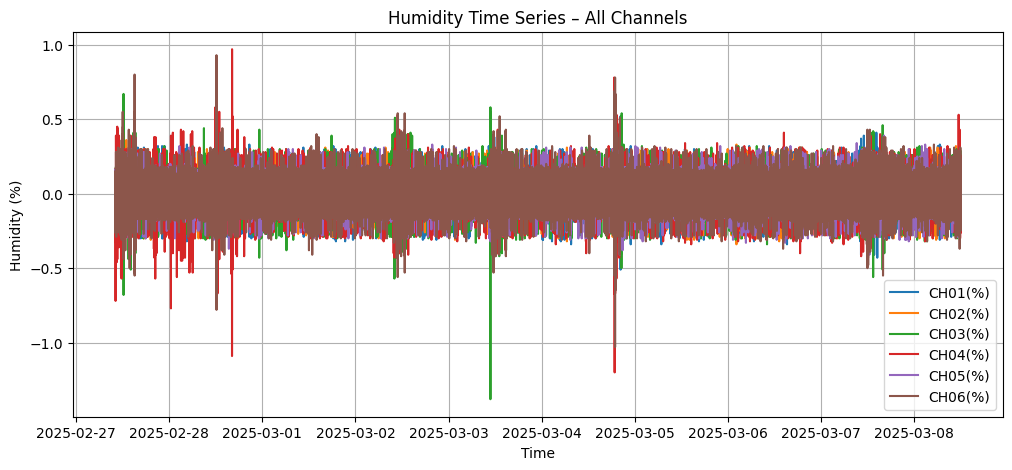

In [35]:
plt.figure(figsize=(12,5))
for col in first_diff.columns:
    plt.plot(first_diff.index, first_diff[col], label=col)

plt.title("Humidity Time Series – All Channels")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
for col in second_diff.columns:
    plt.plot(second_diff.index, second_diff[col], label=col)

plt.title("Humidity Time Series – All Channels")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()

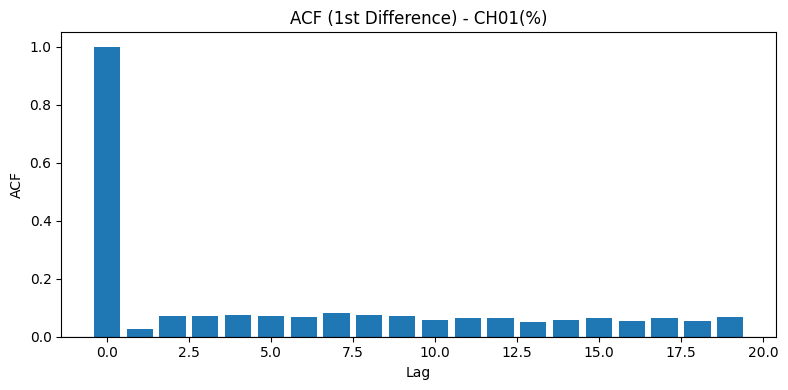

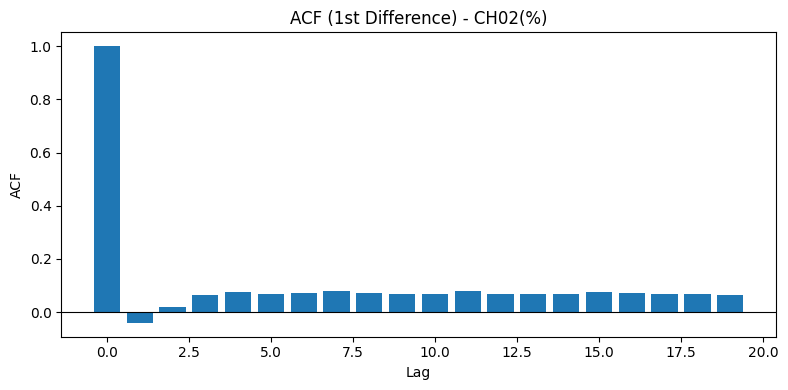

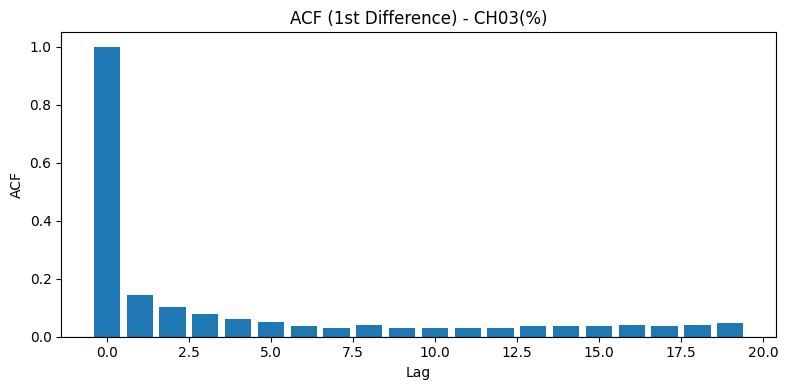

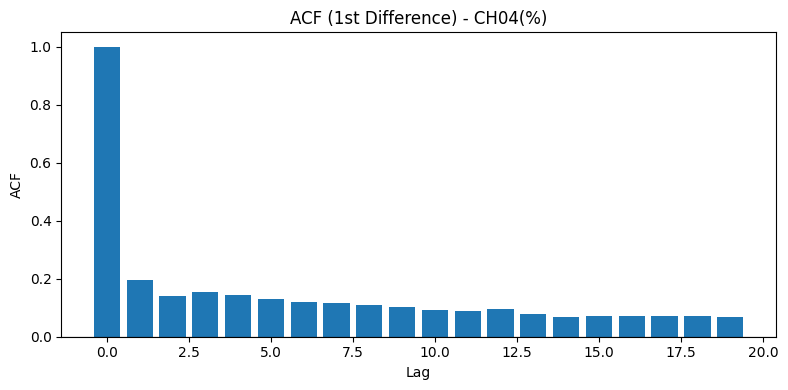

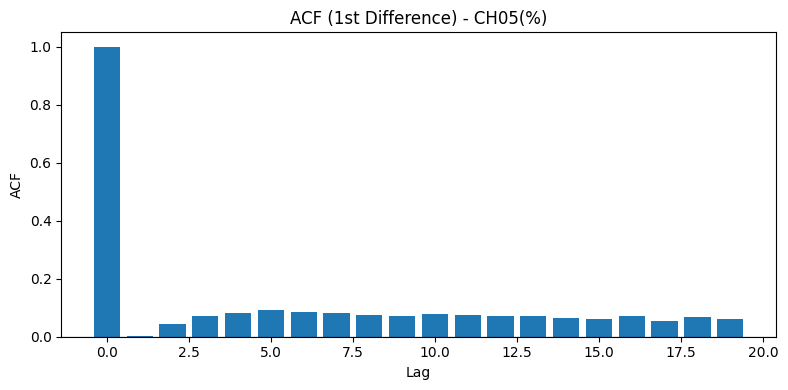

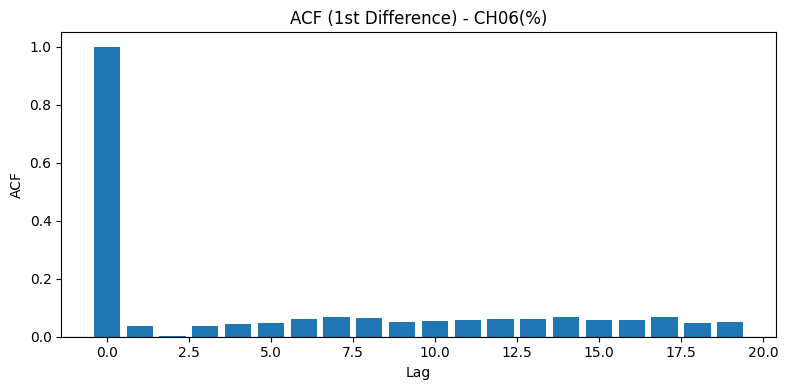

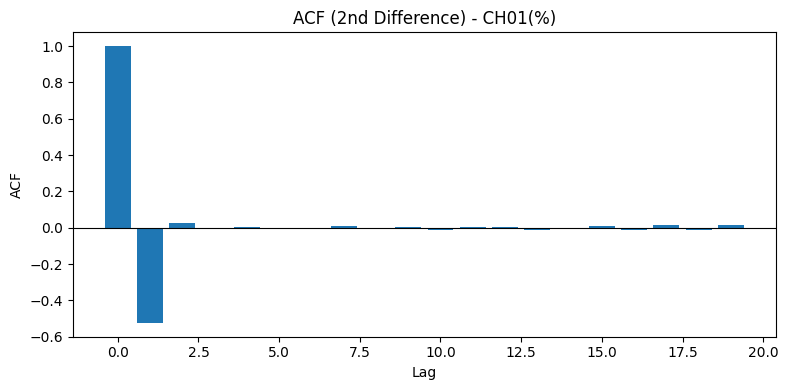

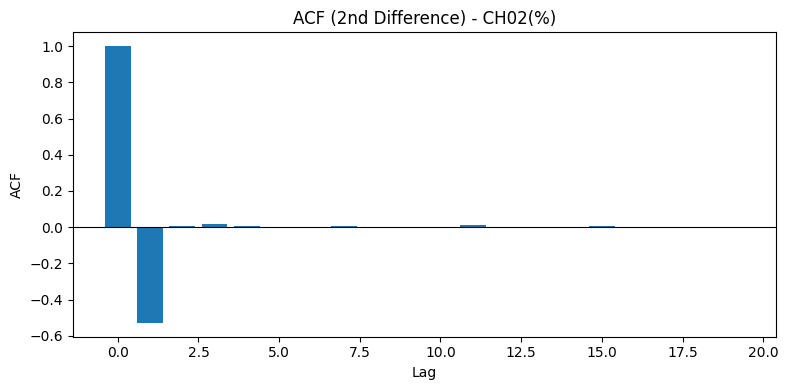

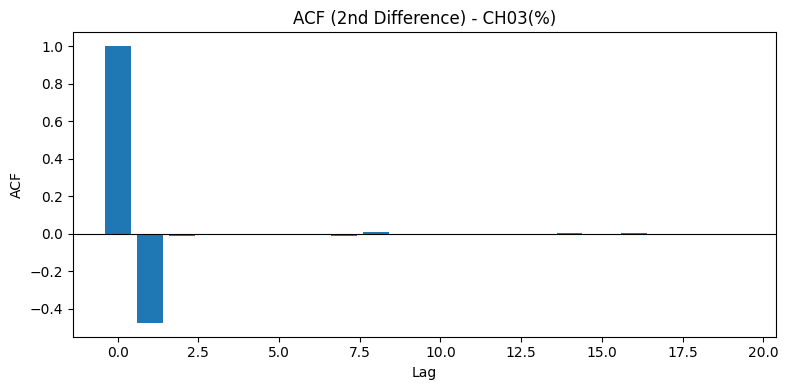

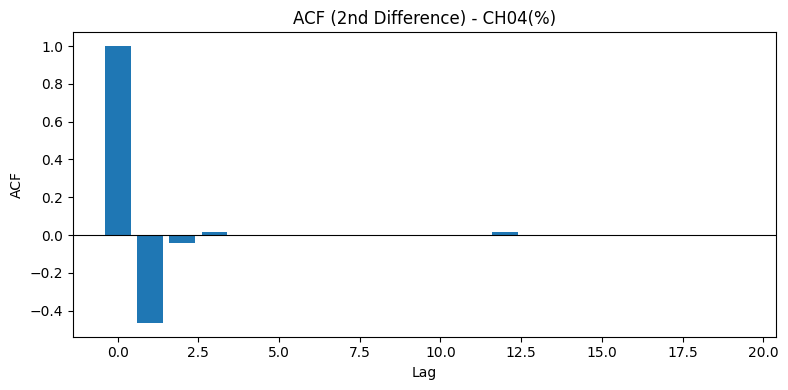

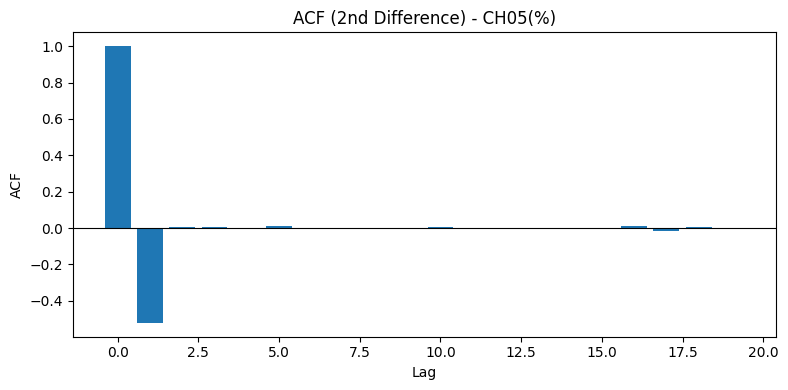

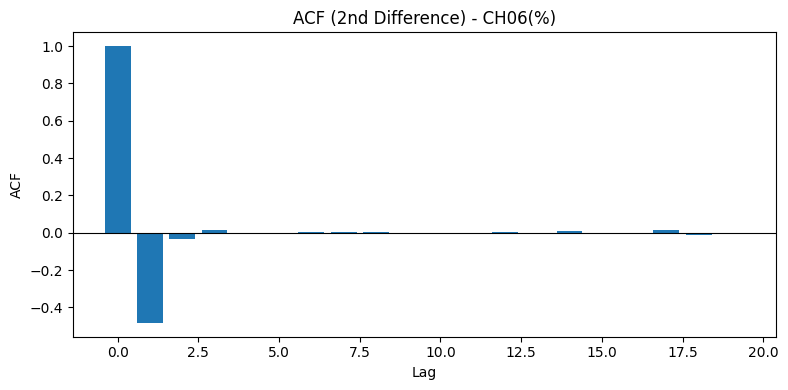

In [37]:
num_lags = 20

for col in first_diff.columns:
    series = first_diff[col].dropna()
    if len(series) < 2:
        print(f"Skipping {col}: not enough data")
        continue

    acf_vals = acf(series, nlags=num_lags-1)

    plt.figure(figsize=(8, 4))
    plt.bar(range(num_lags), acf_vals[:num_lags])
    plt.axhline(0, color="black", linewidth=0.8)
    plt.title(f"ACF (1st Difference) - {col}")
    plt.xlabel("Lag")
    plt.ylabel("ACF")
    plt.tight_layout()
    plt.show()

for col in second_diff.columns:
    series = second_diff[col].dropna()
    if len(series) < 2:
        print(f"Skipping {col}: not enough data")
        continue

    acf_vals = acf(series, nlags=num_lags-1)

    plt.figure(figsize=(8, 4))
    plt.bar(range(num_lags), acf_vals[:num_lags])
    plt.axhline(0, color="black", linewidth=0.8)
    plt.title(f"ACF (2nd Difference) - {col}")
    plt.xlabel("Lag")
    plt.ylabel("ACF")
    plt.tight_layout()
    plt.show()    

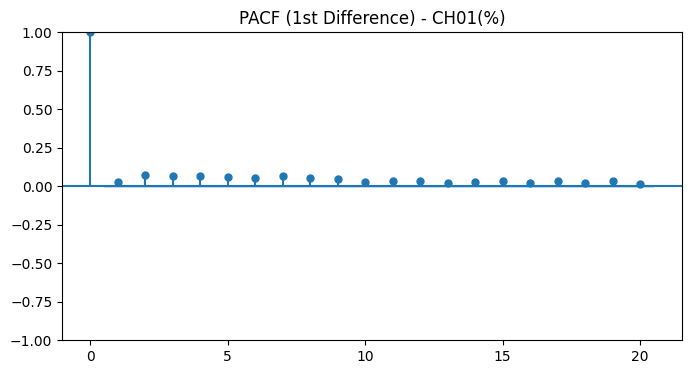

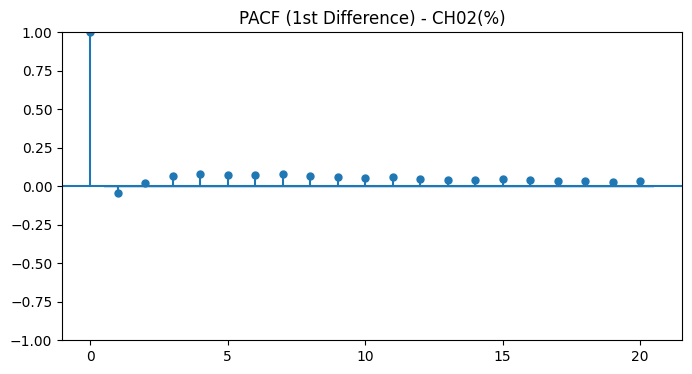

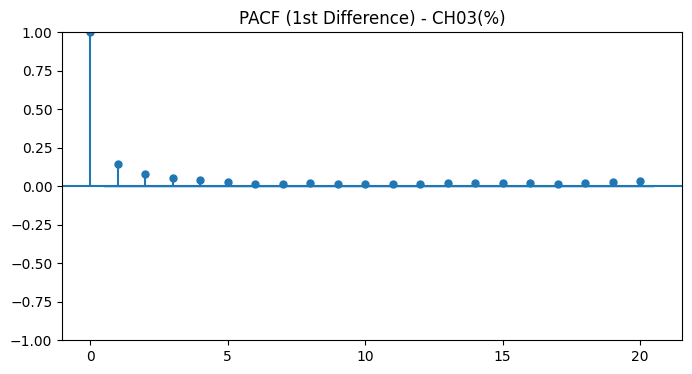

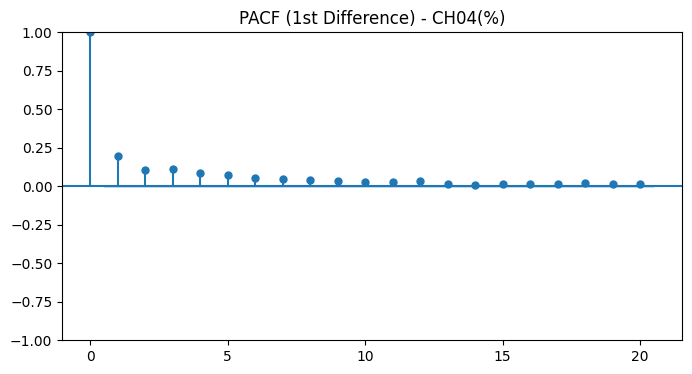

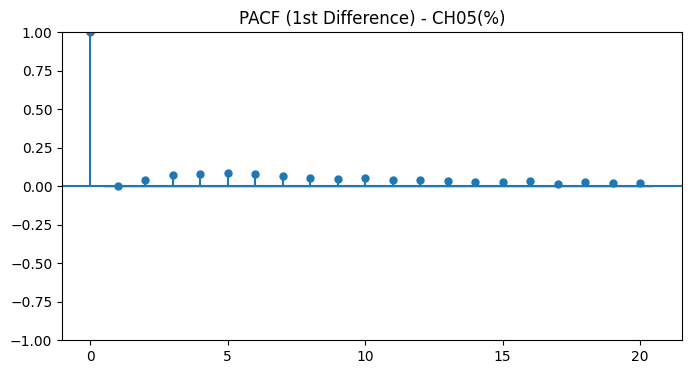

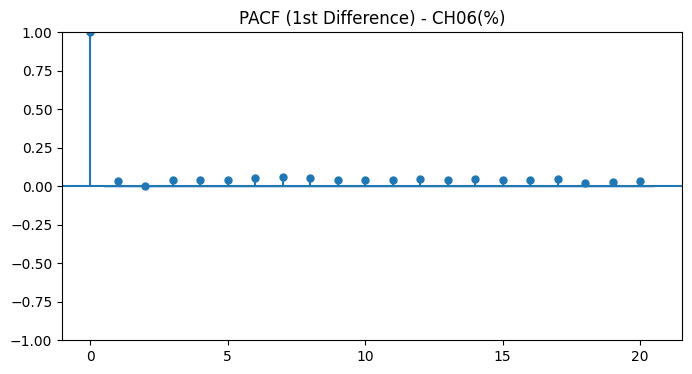

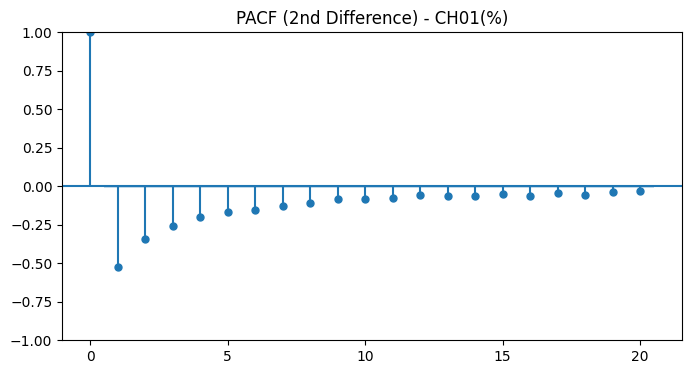

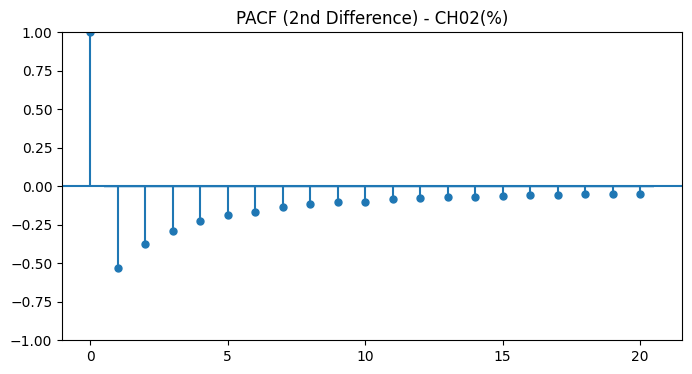

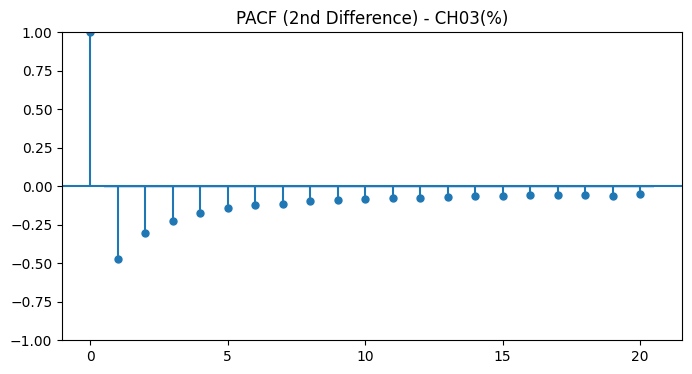

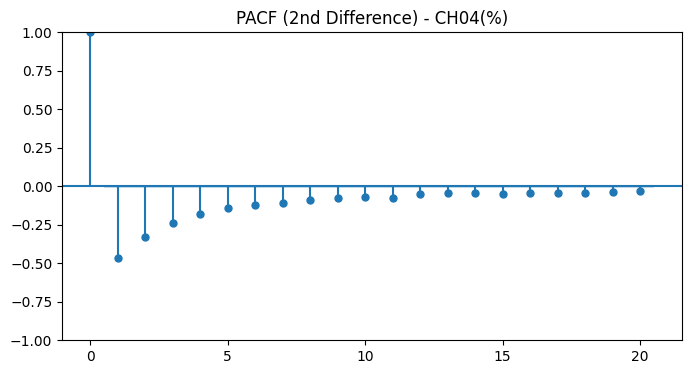

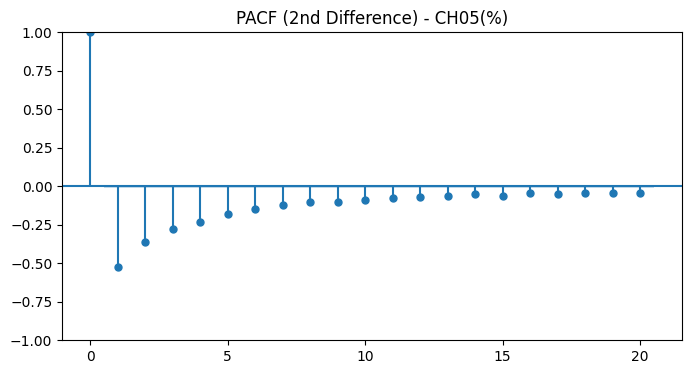

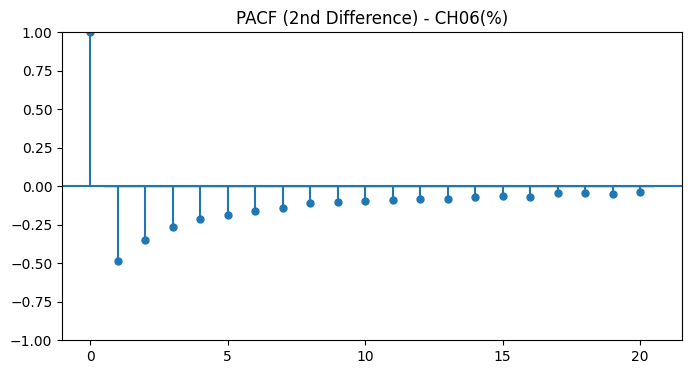

In [38]:
for column in first_diff.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    # 'method' can be 'yw' (default) or 'ols'
    plot_pacf(first_diff[column].dropna(), lags=20, ax=ax, title=f'PACF (1st Difference) - {column}')
    plt.show()

for column in second_diff.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    # 'method' can be 'yw' (default) or 'ols'
    plot_pacf(second_diff[column].dropna(), lags=20, ax=ax, title=f'PACF (2nd Difference) - {column}')
    plt.show()

In [39]:
# Choose one channel
y = second_diff['CH04(%)'].copy()

# Ensure numeric and handle error codes
y = pd.to_numeric(y, errors='coerce').replace(-32640, np.nan)

# Sort time
y = y.sort_index()

# Align timestamps to nearest n minutes and aggregate duplicates
n = 60  # Example: align to nearest 60 minutes
y.index = y.index.round(f'{n}min')
y = y.groupby(level=0).mean()

# Enforce strict n-min frequency
y = y.asfreq(f'{n}min')

# Fill small gaps (safe for short-term forecasting)
y = y.interpolate('time').ffill().bfill()

# Train/test split
split = int(len(y) * 0.8)
train = y.iloc[:split]
test  = y.iloc[split:]  

In [41]:

model = pm.auto_arima(
    train,
    seasonal=True,        
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=-2152.280, Time=0.13 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-2063.574, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-2106.341, Time=0.08 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-2147.500, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-2065.481, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-2158.435, Time=0.21 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=-2160.090, Time=0.18 sec
 ARIMA(0,0,3)(0,0,0)[0] intercept   : AIC=-2057.555, Time=0.13 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-2148.438, Time=0.11 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=-2156.189, Time=0.28 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-2162.396, Time=0.16 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-2149.513, Time=0.09 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-2160.354, Time=0.08 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=-2059.470, Time=0.09 sec
 ARIMA(1,0,1)(0,0,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  175
Model:               SARIMAX(2, 0, 4)   Log Likelihood                1088.688
Date:                Thu, 09 Apr 2026   AIC                          -2163.375
Time:                        16:39:36   BIC                          -2141.222
Sample:                    02-27-2025   HQIC                         -2154.389
                         - 03-06-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5856      0.041    -14.188      0.000      -0.667      -0.505
ar.L2         -0.7530      0.023    -33.174      0.000      -0.798      -0.709
ma.L1         -0.3064      0.059     -5.189      0.000      -0.422      -0.191
ma.L2          0.1978      0.048      4.096      0.000       0.103       0.292
ma.L3         -0.7887      0.060    -13.050      0.000      -0.907      -0.670
ma.L4         -0.0160      0.075     -0.213      0.831      -0.163       0.131
sigma2      2.225e-07   1.86e-08     11.963      0.000    1.86e-07    2.59e-07
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              1015.27
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               0.31   Skew:                            -1.93
Prob(H) (two-sided):                  0.00   Kurtosis:                        14.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 8.29e+16. Standard errors may be unstable.
"""

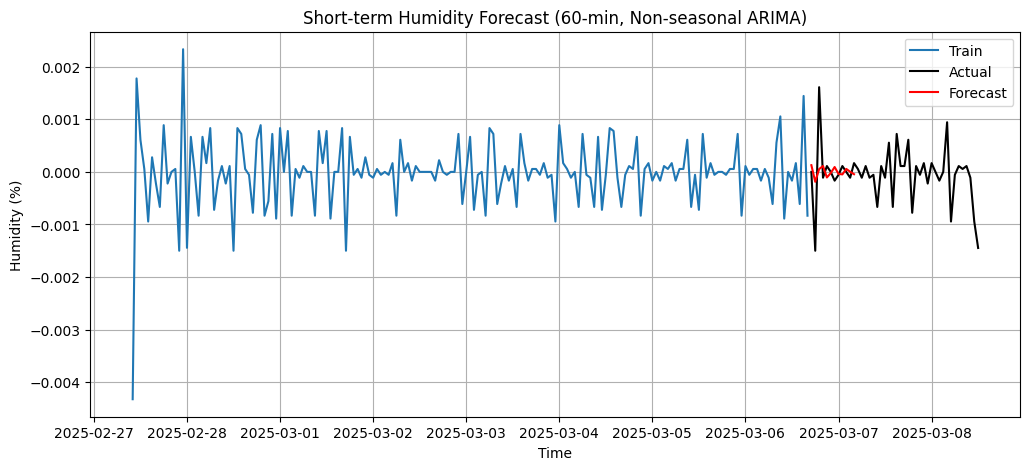

In [43]:

n_periods = 12
forecast = model.predict(n_periods=n_periods)

forecast_index = pd.date_range(start=test.index[0], periods=n_periods, freq='60min')
forecast_series = pd.Series(forecast, index=forecast_index)

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(forecast_series.index, forecast_series, label="Forecast", color="red")
plt.title("Short-term Humidity Forecast (60-min, Non-seasonal ARIMA)")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.grid(True)
plt.legend()
plt.show()


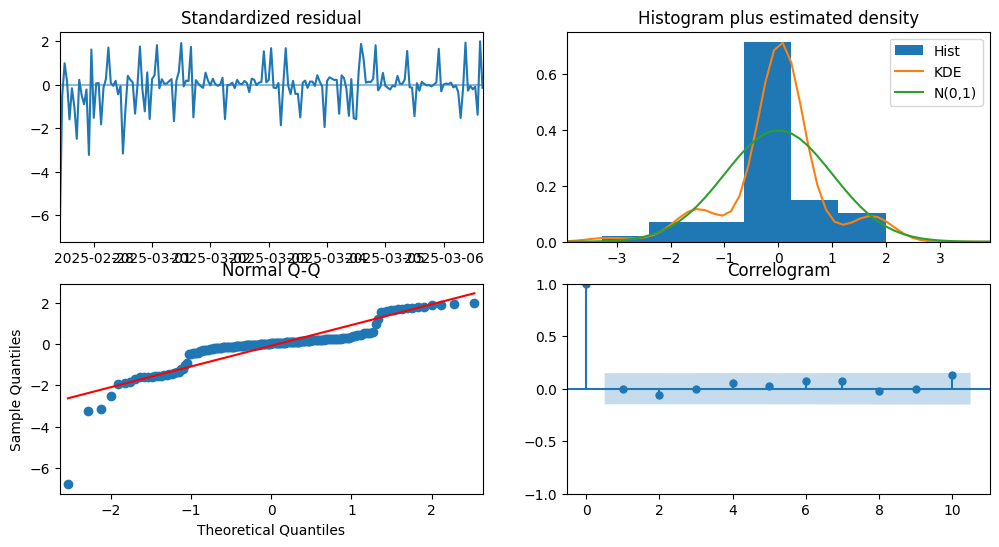

In [44]:
model.plot_diagnostics(figsize=(12,6))
plt.show()


In [23]:

simple_model = pm.ARIMA(order=(1,0,1), with_intercept=True)
simple_model.fit(train)


n_periods = 12

# Complex model forecast
fc_complex = model.predict(n_periods=n_periods)

# Simple model forecast
fc_simple = simple_model.predict(n_periods=n_periods)
                                 
                                 
actual = test.iloc[:n_periods]

mae_complex = mean_absolute_error(actual, fc_complex)
mae_simple  = mean_absolute_error(actual, fc_simple)

print("Complex ARIMA(2,0,4) MAE:", mae_complex)
print("Simple  ARIMA(1,0,1) MAE:", mae_simple)



Complex ARIMA(2,0,4) MAE: 0.0003562467345575792
Simple  ARIMA(1,0,1) MAE: 0.00033202794967235566


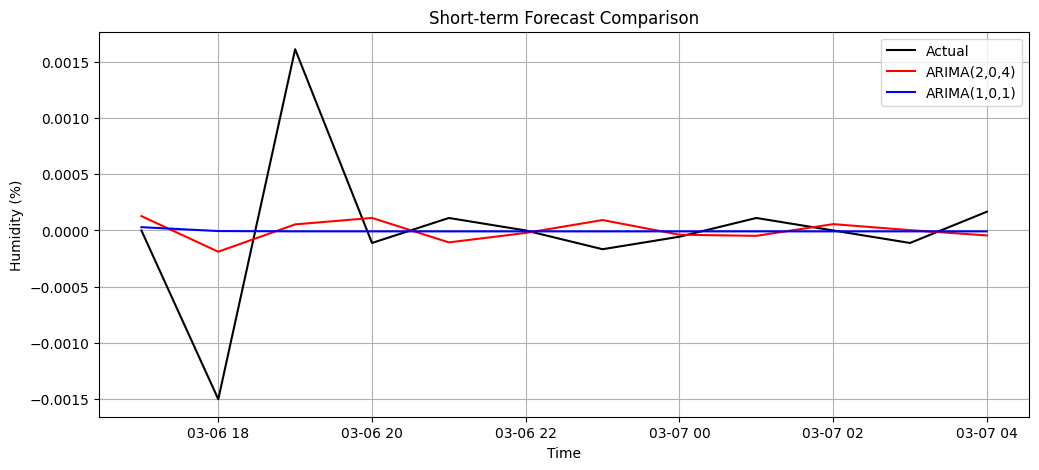

In [24]:

plt.figure(figsize=(12,5))
plt.plot(test.index[:n_periods], actual, label="Actual", color="black")
plt.plot(test.index[:n_periods], fc_complex, label="ARIMA(2,0,4)", color="red")
plt.plot(test.index[:n_periods], fc_simple, label="ARIMA(1,0,1)", color="blue")

plt.title("Short-term Forecast Comparison")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()
